## OpenCV

#### Importing the Libraries

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#### Importing Image

In [2]:
img = cv.imread('../assests/arya_photo.jpg')
cv.imshow('Arya Photo', img)
cv.waitKey(3333)
cv.destroyAllWindows()

#### Importing a video

In [3]:
capture = cv.VideoCapture('../assests/Road_To_Chandratal.mp4')  # 0 -> webcam

while True:
    isTrue, frame = capture.read()

    if not isTrue:
        print("End of video or cannot read the frame.")
        break

    cv.imshow('Road To Chandratal', frame)

    if cv.waitKey(20) & 0xFF == ord('d'):
        break

capture.release()
cv.destroyAllWindows()  

End of video or cannot read the frame.


#### Rescaling size of video

In [4]:
def rescale_frame(frame, scale=0.5): # Images , Videos and Live Videos
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale)
    dimensions = (width, height)
    return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)

def change_res(width, height) : # Only for Live Video
    capture.set(3, width) 
    capture.set(4, height)

capture = cv.VideoCapture('../assests/Road_To_Chandratal.mp4') # 0 -> webcam

while True:
    isTrue, frame = capture.read()

    if not isTrue:
        print("End of video or cannot read the frame.")
        break

    frame_resized = rescale_frame(frame)  # moved after check
    cv.imshow('Road To Chandratal Resized', frame_resized)

    if cv.waitKey(20) & 0xFF == ord('d'):
        break

capture.release()
cv.destroyAllWindows()

End of video or cannot read the frame.


#### Draw on Images

In [5]:
blank = np.zeros((500, 500, 3), dtype = 'uint8')
# 1. Paint the Image A certain color
blank[::50] = 0,255,0
# 2. Paint for the particular height and width
blank[300:500, 300:500] = 0,0,255
# 3. Draw a Rectangle
cv.rectangle(blank, (0,0), (blank.shape[1]//2, blank.shape[0]//2), (0,255,0), thickness = -1 )
# 4. Draw A circle
cv.circle(blank, (250,250), 50, (0,255,255), thickness = -1)
# 5. Draw a Line
cv.line(blank, (0,0), (blank.shape[1], blank.shape[0]), (255,255,0), thickness = 3 )
# 6. Write Text on Image
cv.putText(blank, 'Hello World', (0,225), cv.FONT_HERSHEY_TRIPLEX, 1.0, (0,0,0), 2)
cv.putText(blank, "It's Arya", (325,325), cv.FONT_HERSHEY_TRIPLEX, 1.0, (255,255,255), 2)
cv.imshow('Text, Line, Circle, Squar and Stripe : ', blank)

cv.waitKey(0)

-1

#### 7 Most Essential functions

In [6]:
# 1. Converting Image To Gray Scale
image1 = cv.imread('../assests/Champions_league.png')
image1 = rescale_frame(image1)
gray = cv.cvtColor(image1, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)
cv.imshow('Before Gray', image1)
cv.waitKey(0)

-1

In [7]:
# 2. Blur An Image
image2 = cv.imread('../assests/HEADLINE.png')
blur = cv.GaussianBlur(image2, (5,5), cv.BORDER_DEFAULT)
cv.imshow('Blur', blur)
cv.imshow('Before Blur', image2)
cv.waitKey(0)

-1

In [8]:
# 3. Edge Cascade
image3 = cv.imread('../assests/interview.png')
canny = cv.Canny(image3, 125, 175)
cv.imshow('Canny Edges', canny)
cv.imshow('Before Canny Edges', image3)
cv.waitKey(0)

-1

In [9]:
# 4. Dialating the images
dilated = cv.dilate(canny, (5,5), iterations = 2)
cv.imshow('Dilated Image', dilated)
cv.imshow('Before Dilated Image', canny)
cv.waitKey(0)

-1

In [10]:
# 5. Eroding
eroded = cv.erode(dilated, (5,5), iterations = 2)
cv.imshow('Eroded', eroded)
cv.imshow('Before Eroded', dilated)
cv.waitKey(0)

-1

In [11]:
# 6 Resize
image4 = cv.imread('../assests/injury.png')
resized = cv.resize(image4, (1000,500), interpolation = cv.INTER_AREA)
cv.imshow('Resized', resized)
cv.waitKey(0)

-1

In [12]:
# 7. Cropped Image
cropped = image4[100:400, 200:500]
cv.imshow("Cropped", cropped)
cv.waitKey(0)

-1

#### Transformation Functions

In [13]:
# Translation
def translate(image1, x, y):
    transMat = np.float32([[1,0,x],[0,1,y]])
    dimensions = (image1.shape[1], image1.shape[0])
    return cv.warpAffine(image1, transMat, dimensions) # -x -> left ; -y-> up

translated = translate(image1, 100, 100)
cv.imshow('Translated', translated)
cv.imshow('Before Translated', image1)
cv.waitKey(0)

-1

In [14]:
# Rotation
def rotate(img, angle, rotPoint = None) :
    (height, width) = image2.shape[:2]

    if rotPoint == None :
        rotPoint = (width//2, height//2)

    rotMat = cv.getRotationMatrix2D(rotPoint, angle, 1.0)
    dimensions = (width, height)

    return cv.warpAffine(image2, rotMat, dimensions)

rotated = rotate(image2, 45)
cv.imshow('Rotated Image', rotated)
cv.imshow('Before Rotated Image', image2)
cv.waitKey(0)

-1

In [15]:
# Flipping
flip = cv.flip(image3, 1) # 0 -> vertical, 1 -> horizontal , -1 -> both
cv.imshow('Flipped Image', flip)
cv.imshow('Before Flip Image', image3)
cv.waitKey(0)

-1

#### Contour Detection

In [16]:
image5 = cv.imread('../assests/record.png')
image5 = cv.resize(image5, (500,500), interpolation = cv.INTER_CUBIC)

blank = np.zeros(image5.shape, dtype = 'uint8')
gray = cv.cvtColor(image5, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray, 125, 255, cv.THRESH_BINARY)
blur = cv.GaussianBlur(gray, (5,5), cv.BORDER_DEFAULT)
canny = cv.Canny(blur, 125, 175)
contours, hierarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_NONE)

cv.drawContours(blank, contours, -1, (0,0,255), 1)

cv.imshow('Contours Drawn', blank)
cv.imshow('Original', image5)
cv.imshow('Gray', gray)
cv.imshow('Blur', blur)
cv.imshow('Canny Edges', canny)
cv.imshow('Thresh', thresh)

print(f'{len(contours)}, Contours are found')

cv.waitKey(0)

414, Contours are found


-1

### Switch between color spaces

In [17]:
cv.imshow('Image 5',image5)

# BGR to Gray Scale
gray = cv.cvtColor(image5, cv.COLOR_BGR2GRAY)
# Gray Scale to BGR
gray_to_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR) # return gray color only

# BGR TO L*A*B
lab = cv.cvtColor(image5, cv.COLOR_BGR2LAB)
# BGR TO L*A*B
lab_to_bgr = cv.cvtColor(lab, cv.COLOR_LAB2BGR)

# BGR to HSV
hsv = cv.cvtColor(image5, cv.COLOR_BGR2HSV)
# BGR to HSV
hsv_to_bgr = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)

# BGR TO RGB
rgb = cv.cvtColor(image5, cv.COLOR_BGR2RGB)
# BGR TO RGB
rgb_to_bgr = cv.cvtColor(rgb, cv.COLOR_RGB2BGR)

cv.imshow('BGR --> Gray', gray)
cv.imshow('BGR --> LAB', lab)
cv.imshow('BGR --> HSV', hsv)
cv.imshow('BGR --> RGB', rgb)
cv.imshow('Gray --> BGR', gray_to_bgr)
cv.imshow('HSV --> BGR', hsv_to_bgr)
cv.imshow('LAB --> BGR', lab_to_bgr)
cv.imshow('RGB --> BGR', rgb_to_bgr)

cv.waitKey(0)

-1

In [18]:
cv.imshow('Image - 1', img)

blank = np.zeros(img.shape[:2], dtype = 'uint8')
b,g,r = cv.split(img)
merged = cv.merge([b,g,r])
blue = cv.merge([b, blank, blank])
green = cv.merge([blank, g, blank])
red = cv.merge([blank, blank, r])

cv.imshow('Blue Intensity', b)
cv.imshow('Green Intensity', g)
cv.imshow('Red Intensity', r)
cv.imshow('Blue', blue)
cv.imshow('Green', green)
cv.imshow('Red', red)
cv.imshow('',merged)

print(img.shape)
print(b.shape)
print(g.shape)
print(r.shape)

cv.waitKey(0)

(661, 625, 3)
(661, 625)
(661, 625)
(661, 625)


-1

#### Smoothing and Blurring

In [19]:
cv.imshow('Image 5',image5)

# Averaging
average = cv.blur(image5, (5,5))
cv.imshow('Average Blur', average)

# Gaussian
gaussian = cv.GaussianBlur(image5, (5,5), 0)
cv.imshow('Gaussian Blur', gaussian)

# Median
median = cv.medianBlur(image5, 5)
cv.imshow('Median', median)

# Bilateral
bilateral = cv.bilateralFilter(image5, 5, 30, 30)
cv.imshow('Bilateral Blur', bilateral)

cv.waitKey(0)

-1

#### Bitwise Operations

In [20]:
blank = np.zeros((400, 400), dtype = 'uint8')
rectangle = cv.rectangle(blank.copy(), (30,30), (370,370), 255, -1)
circle = cv.circle(blank.copy(), (200,200), 200, 255, -1)

# bitwise AND
bitwise_and = cv.bitwise_and(rectangle,circle)
# bitwise OR
bitwise_or = cv.bitwise_or(rectangle, circle)
# bitwise Xor
bitwise_xor = cv.bitwise_xor(rectangle, circle)
# bitwise Not
bitwise_not_circle = cv.bitwise_not(circle)
bitwise_not_rectangle = cv.bitwise_not(rectangle)

cv.imshow('Rectangle', rectangle)
cv.imshow('Circle', circle)
cv.imshow('Bitwise And',bitwise_and)
cv.imshow('Bitwise Or',bitwise_or)
cv.imshow('Bitwise Xor',bitwise_xor)
cv.imshow('Bitwise Not on Circle',bitwise_not_circle)
cv.imshow('Bitwise Not on Rectangle',bitwise_not_rectangle)

cv.waitKey(0)

-1

#### Masking 

In [21]:
blank = np.zeros(img.shape[:2], dtype = 'uint8')
mask = cv.circle(blank, (img.shape[1]//2, img.shape[0]//2), 100, 255, -1)
masked = cv.bitwise_and(img,img, mask = mask)

cv.imshow('Original Image', img)
cv.imshow('Mask', mask)
cv.imshow('Masked Image', masked)

cv.waitKey(0)

-1

#### Histogram 

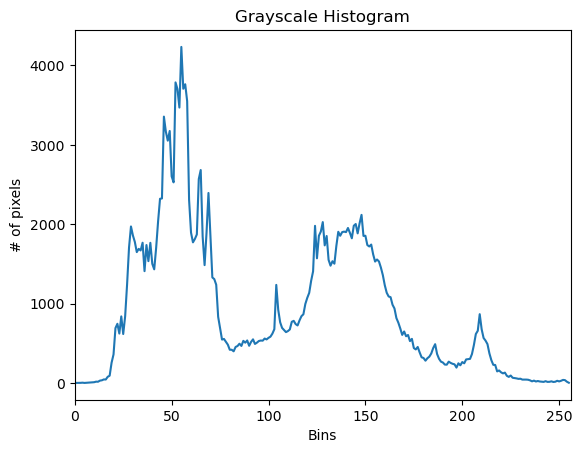

-1

In [22]:
gray = cv.cvtColor(image3, cv.COLOR_BGR2GRAY)
gray_hist = cv.calcHist([gray], [0], None, [256], [0,256])
blank = np.zeros(image3.shape[:2], dtype = 'uint8')
circle = cv.circle(blank, (image3.shape[1]//2,image3.shape[0]//2), 100, 255, -1)
mask = cv.bitwise_and(gray,gray, mask = circle)
cv.imshow('MASK',mask)

plt.figure()
plt.title('Grayscale Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')
plt.plot(gray_hist)
plt.xlim([0,256])
plt.show()

cv.waitKey(0)

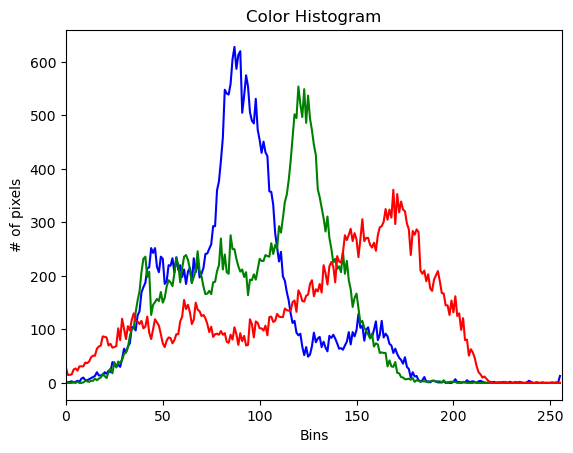

-1

In [23]:
blank = np.zeros(image3.shape[:2], dtype = 'uint8')
mask = cv.circle(blank, (image3.shape[1]//2,image3.shape[0]//2), 100, 255, -1)
masked = cv.bitwise_and(image3,image3, mask = mask)
cv.imshow('MASK',masked)

plt.figure()
plt.title('Color Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')

colors = ('b', 'g', 'r')
for i,col in enumerate(colors) :
    hist = cv.calcHist([image3], [i], mask, [256], [0,256])
    plt.plot(hist, color = col)
    plt.xlim([0,256])

plt.show()

cv.waitKey(0)

#### Thresholing value

In [24]:
gray = cv.cvtColor(image3, cv.COLOR_BGR2GRAY)
threshold, thresh = cv.threshold(gray, 128, 255, cv.THRESH_BINARY)
cv.imshow('Simple thresholded', thresh)
threshold, thresh_inv = cv.threshold(gray, 128, 255, cv.THRESH_BINARY_INV)
cv.imshow('Simple thresholded Inverse', thresh_inv)
cv.waitKey(0)

-1

In [25]:
gray = cv.cvtColor(image3, cv.COLOR_BGR2GRAY)

adaptive_thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 3)
cv.imshow('Adaptive Thresholding', adaptive_thresh)
cv.waitKey(0)

-1

#### Gradients

In [26]:
# Laplacian
lap = cv.Laplacian(gray, cv.CV_64F)
lap = np.uint8(np.absolute(lap))
cv.imshow('Laplacian', lap)

canny = cv.Canny(lap, 150, 175)
cv.imshow('Canny', canny)

cv.waitKey(0)

-1

In [27]:
#sobel
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1)
sobel_union = cv.bitwise_or(sobelx, sobely)

cv.imshow('Sobel X', sobelx)
cv.imshow('Sobel Y', sobely)
cv.imshow('Sobel Union', sobel_union)

cv.waitKey(0)

-1